In [1]:
import numpy as np

X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

print("X:", X)
print("y:", y)

X: [50 60 70 80 90]
y: [150 180 210 240 270]


In [8]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.sse_history = []

    def fit(self, X, y):
        n = len(X)
        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            
            # Calculate Sum of Squared Errors (SSE)
            sse = np.sum((y - y_pred) ** 2)
            self.sse_history.append(sse)
            
            # Calculate gradients
            d_theta_0 = (2 / n) * np.sum(y_pred - y)
            d_theta_1 = (2 / n) * np.sum((y_pred - y) * X)
            
            # Update parameters
            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X

In [9]:

model = LinearRegressionGD(learning_rate=0.0001, n_iters=100)
model.fit(X, y)
print("theta_0 (intercept):", model.theta_0)
print("theta_1 (slope):", model.theta_1)

theta_0 (intercept): 0.04113676040970018
theta_1 (slope): 2.999435373457505


In [10]:
predicted_price = model.predict(70)
print("Predicted price for 70 m2 house:", predicted_price)

Predicted price for 70 m2 house: 210.00161290243506


Is the prediction reasonable based on the dataset? Why?
Yes, it is very reasonable because $70 \times 3 = 210$, which matches the exact linear pattern in the training dataset ($y = 3X$).

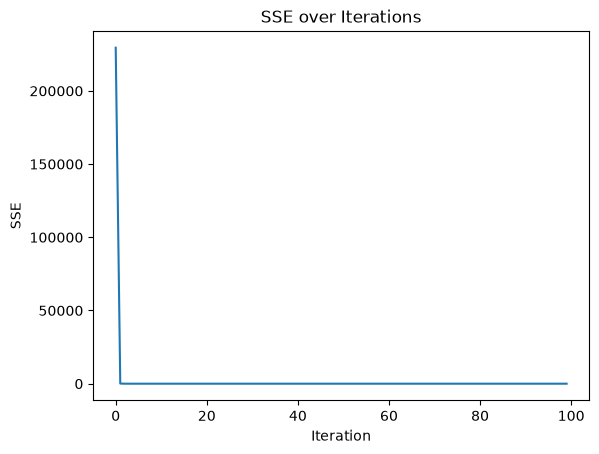

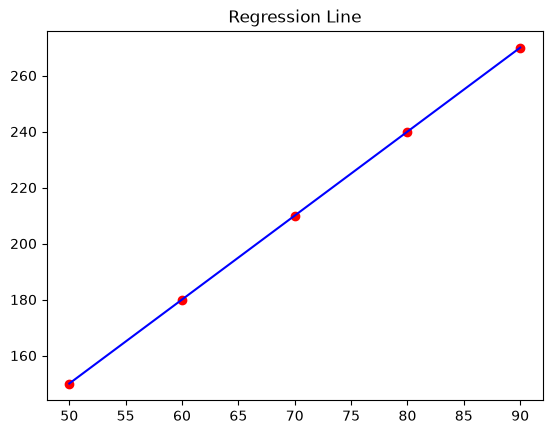

In [11]:
import matplotlib.pyplot as plt
plt.plot(model.sse_history)
plt.title("SSE over Iterations")
plt.xlabel("Iteration")
plt.ylabel("SSE")
plt.show()
plt.scatter(X, y, color='red')
plt.plot(X, model.predict(X), color='blue')
plt.title("Regression Line")
plt.show()

In [12]:

model_small = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
model_small.fit(X, y)
model_large = LinearRegressionGD(learning_rate=0.01, n_iters=100)
model_large.fit(X, y)
print("Small LR Final SSE:", model_small.sse_history[-1])
print("Large LR Final SSE:", model_large.sse_history[-1])

Small LR Final SSE: 0.00046041150816733306
Large LR Final SSE: inf


C:\Users\HP\AppData\Local\Temp\ipykernel_16444\121519767.py:15: RuntimeWarning: overflow encountered in square
  sse = np.sum((y - y_pred) ** 2)


In [13]:

def calculate_mse(sse, n):
    return sse / n

X_norm = (X - np.min(X)) / (np.max(X) - np.min(X))

model_bonus = LinearRegressionGD(learning_rate=0.1, n_iters=100)
model_bonus.fit(X_norm, y)

print("MSE:", calculate_mse(model_bonus.sse_history[-1], len(X)))

MSE: 2.0302147628117013
